In [ ]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models.utils import animate_field_1d
import matplotlib.pyplot as plt
from Modeling.models.ROM import ROM

import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [ ]:
%matplotlib widget

Q = 300
params = PiezoBeamParams( 
    Q = Q, L_b=3.185
    )
params.zeta_p = 0.0151/100
params.zeta_q = 0.0392/100
N = 200
rom = ROM(params, N=N)


#%%
x_eval = np.linspace(0, rom.p.L_b, 500)

K_i = 60; K_p = 1e-4; K_c = 0

f0 = 200; f1 = 500

j_exc = 299
freq_modal, vel_mag, disp_mag, veloc_frq = rom.frequency_response(j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i,
										w=np.linspace(f0, f1, 500)*2*np.pi, x_eval=x_eval)
# %matplotlib widget
plt.figure(figsize=(12, 4))
# plt.semilogy(frq_linear_exp, np.mean(frf_data_linear_exp[:,:], axis=1), 'r--', label=' Experiment')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w']*2*pi*comsol_OC['freq'], 'g-', label='COMSOL ')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w'], 'g-', label='COMSOL displacement FRF')
# plt.semilogy(frq_OC_exp, np.mean(frf_data_OC_exp[:,:], axis=1), 'k--', label=f'Open circuit Exp.')
# plt.semilogy(frq_SC_exp, np.mean(frf_data_SC_exp[:,:], axis=1), 'b--', label=f'Short circuit Exp.')
# plt.semilogy(freq_modal, vel_mag, '.-', label='Modal Reduced Order'   )
# plt.semilogy(freq, FRF, '.-', linewidth=1.5, label='Time Domain ROM')
plt.semilogy(freq_modal, vel_mag, '.-', label='Frequency Domain ROM'   )
# plt.semilogy(frq_OC_exp, np.mean(frf_data_OC_exp[:,:], axis=1), 'k--', label=f'Experiment')
# plt.semilogy(frq_linear, np.mean(frf_data_linear[:,:], axis=1), 'r--', label=' Exp.')

# plt.semilogy(freq_modal, disp_mag*freq_modal*2*np.pi, '-', label='Modal Reduced Order Displacement $j \omega$'   )
plt.legend()
# plt.xlim([1300, 3000])
# plt.xlim([f0, f1])
# plt.ylim([1e-5, 1e-3])
# plt.ylim([3e-5, 6e-4])
plt.xlabel("Frequency [Hz]")
plt.ylabel("AverageVelocity/Voltage FRF")
plt.grid(True)
plt.show()


In [ ]:
R_c = 1e3; K_c = 16e5
def compute_scales(rom, K_i, K_c, R_c):
    return rom.nondimensional_scales(K_i=K_i, K_c=K_c, R_c=R_c)
def dispersion_relation(Omega, delta):
    """
    Returns propagating branch q(Omega) for the homogenized lattice
    """
    q4 = (Omega**4 - Omega**2) / ((1 + delta**2)*Omega**2 - 1)
    mask = q4 >= 0
    return Omega[mask], q4[mask]**0.25

def dispersion_derivatives(Omega, q):
    dOmega_dq = np.gradient(Omega, q)
    d2Omega_dq2 = np.gradient(dOmega_dq, q)
    return dOmega_dq, d2Omega_dq2

def nlse_coefficients(Omega0, q0, d2Omega_dq2, Lc_bar):
    """
    Computes NLSE coefficients P and Q at (q0, Omega0)
    """
    P = 0.5 * d2Omega_dq2

    Q = (
        -3 * np.sign(Lc_bar)
        / (2 * Omega0)
        * (1 - Omega0**2)
        / ((1 - Omega0**2 + q0**4) * (Omega0**2 + 1))
    )

    return P, Q, (P * Q > 0)

def envelope_soliton(x, t, P, Q, phi0, eps, q0, Omega0, vg):
    arg = eps * phi0 * np.sqrt(Q / (2 * P)) * (x - vg * t)

    A = (
        eps * phi0
        / np.cosh(arg)
        * np.exp(1j * (q0 * x - Omega0 * t))
        * np.exp(0.5 * eps**2 * Q * phi0**2 * t)
    )

    return np.real(A)

def plot_dispersion(q, Omega, x0, t0, k_ridge=None, freq=None, nondim=False):
    plt.figure(figsize=(6, 4))
    if nondim:
        plt.plot(q, Omega, '.', lw=2)
    else:
        plt.plot(q/x0, Omega/t0/(2*np.pi), '.', lw=2)

    if k_ridge is not None:
        plt.scatter(k_ridge, freq, c='r', s=15, alpha=0.3)

    plt.xlabel(r'$q$')
    plt.ylabel(r'$\Omega$')
    plt.title('Dispersion relation and propagation bands')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_soliton(x, w):
    plt.figure(figsize=(7, 3))
    plt.plot(x, w)
    plt.xlabel("x")
    plt.ylabel("Displacement")
    plt.title("NLSE envelope soliton")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def tau1_tau2(
	rom,
	K_c,
	K_i,
	R_c,
	q0,
	delta,
	eps,
	phi0,
	Omega_grid=None
):
	"""
	Compute tau1 and tau2 as functions of:
	(K_c, K_i, R_c, q0, delta, eps, phi0)
	"""

	# --- Dispersion grid ---
	if Omega_grid is None:
		Omega_grid = np.linspace(1e-4, 3.0, 5000)

	Omega_p, q_p = dispersion_relation(Omega_grid, delta)

	# locate operating point
	idx0 = np.argmin(np.abs(q_p - q0))
	Omega0 = Omega_p[idx0]

	# dispersion derivatives
	dOmega_dq, d2Omega_dq2 = dispersion_derivatives(Omega_p, q_p)

	# homogenized circuit parameters
	params = rom.homogenized_parameters(
		K_c=K_c,
		K_i=K_i,
		R_c=R_c
	)
	Lc_bar = params["Lc_bar"]

	# NLSE coefficients
	P, Q, _ = nlse_coefficients(
		Omega0,
		q0,
		d2Omega_dq2[idx0],
		Lc_bar
	)

	# --- tau definitions ---
	tau2 = 0.5 * eps**2 * Q * phi0**2

	tau1 = (
		eps
		* phi0
		* np.sqrt(Q / (2 * P))
		* dOmega_dq[idx0]
	)

	return {
		"tau1": tau1,
		"tau2": tau2,
		"P": P,
		"Q": Q,
		"Omega0": Omega0,
		"Lc_bar": Lc_bar
	}

# --- Parameters ---
delta = 0.5
q_target = 1.0
eps = 0.05
phi0 = 1.0
t = 30

# --- Scales ---
scales = compute_scales(rom, K_i, K_c+0.001, R_c)
t0, x0 = scales['t0'], scales['x0']

# --- Dispersion ---
Omega = np.linspace(1e-4, 3.0, 5000)
Omega_p, q_p = dispersion_relation(Omega, delta)

# --- Operating point ---
idx0 = np.argmax(np.abs(q_p - q_target))
Omega0, q0 = Omega_p[idx0], q_p[idx0]

# --- Derivatives ---
dOmega_dq, d2Omega_dq2 = dispersion_derivatives(Omega_p, q_p)

# --- Homogenized parameters ---
params = rom.homogenized_parameters(R_c=R_c, K_c=K_c, K_i=K_i)
Lc_bar = params['Lc_bar']

# --- NLSE coefficients ---
P, Q, focusing = nlse_coefficients(
    Omega0, q0, d2Omega_dq2[idx0], Lc_bar
)

print("Focusing NLSE" if focusing else "Defocusing NLSE")

# --- Group velocity ---
vg = (dOmega_dq[idx0] / t0) * x0

# --- Soliton ---
x = np.linspace(0, 100.0, 2000)
w = envelope_soliton(x, t, P, Q, phi0, eps, q0, Omega0, vg)

# --- Plots ---
plot_dispersion(q_p, Omega_p, x0, t0)
plot_soliton(x, w)
print("P =", P, " Q =", Q)
def v_exc(t):
    return envelope_soliton(x=0, t=t/t0, P=P, Q=Q, phi0=phi0, eps=eps, q0=q0, Omega0=Omega0, vg=vg)

In [ ]:
np.geomspace(1e4, 1e6, 80)   # adjust range as needed

In [ ]:
# --- Sweep parameters ---
Kc_vals = np.geomspace(1e4, 1e6, 80)   # adjust range as needed
tau1_vals = np.zeros_like(Kc_vals)
tau2_vals = np.zeros_like(Kc_vals)

for i, Kc in enumerate(Kc_vals):
	out = tau1_tau2(
		rom=rom,
		K_c=Kc,
		K_i=K_i,
		R_c=R_c,
		q0=q0,
		delta=delta,
		eps=eps,
		phi0=phi0
	)

	tau1_vals[i] = out["tau1"]
	tau2_vals[i] = out["tau2"]
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

# plt.plot(Kc_vals, tau1_vals, 'o-', label=r'$\tau_1$')
plt.semilogx(Kc_vals, tau2_vals, 's-', label=r'$\tau_2$')

plt.xlabel(r'$K_c$')
plt.ylabel(r'$\tau$')
plt.title(r'NLSE time scales vs $K_c$')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
dOmega_dq[idx0]

tau1=  nan  tau2=  -5.800545135704783e-07
 K_i=  60 K_p=  0.0001  K_c=  1600000.0  R_c=  1000.0


C:\Users\setemadi3\AppData\Local\Temp\ipykernel_36176\1790710739.py:5: RuntimeWarning: invalid value encountered in sqrt
  tau1 = eps * phi0 * np.sqrt(Q / (2 * P)) * dOmega_dq[idx0]


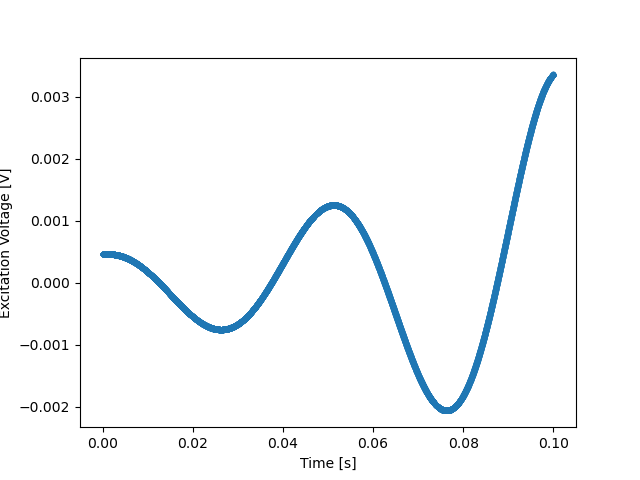

In [67]:

# def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
# 	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
t_end = 0.1
tau2 = 0.5 * eps**2 * Q * phi0**2 
tau1 = eps * phi0 * np.sqrt(Q / (2 * P)) * dOmega_dq[idx0]
print("tau1= ", tau1, " tau2= ", tau2)
print( " K_i= ", K_i,"K_p= ", K_p, " K_c= ", K_c, " R_c= ", R_c)
f_exc = 20
def v_exc(t, A_exc=5, f_exc=f_exc, t_end=t_end, tau1= 20, tau2=0.01):
	# t = t/t0
	tc = t_end / 2
	t = t #- tc
	envelope = 1 / np.cosh(10+ -tau1 * t) * np.exp(tau2 * t)
	return A_exc * envelope * np.cos(2*np.pi*f_exc*t)

t_eval = np.arange(0, t_end, 1e-5)
plt.figure()
plt.plot(t_eval, v_exc(t_eval), '.-' )
plt.xlabel('Time [s]')
plt.ylabel('Excitation Voltage [V]')
plt.show()


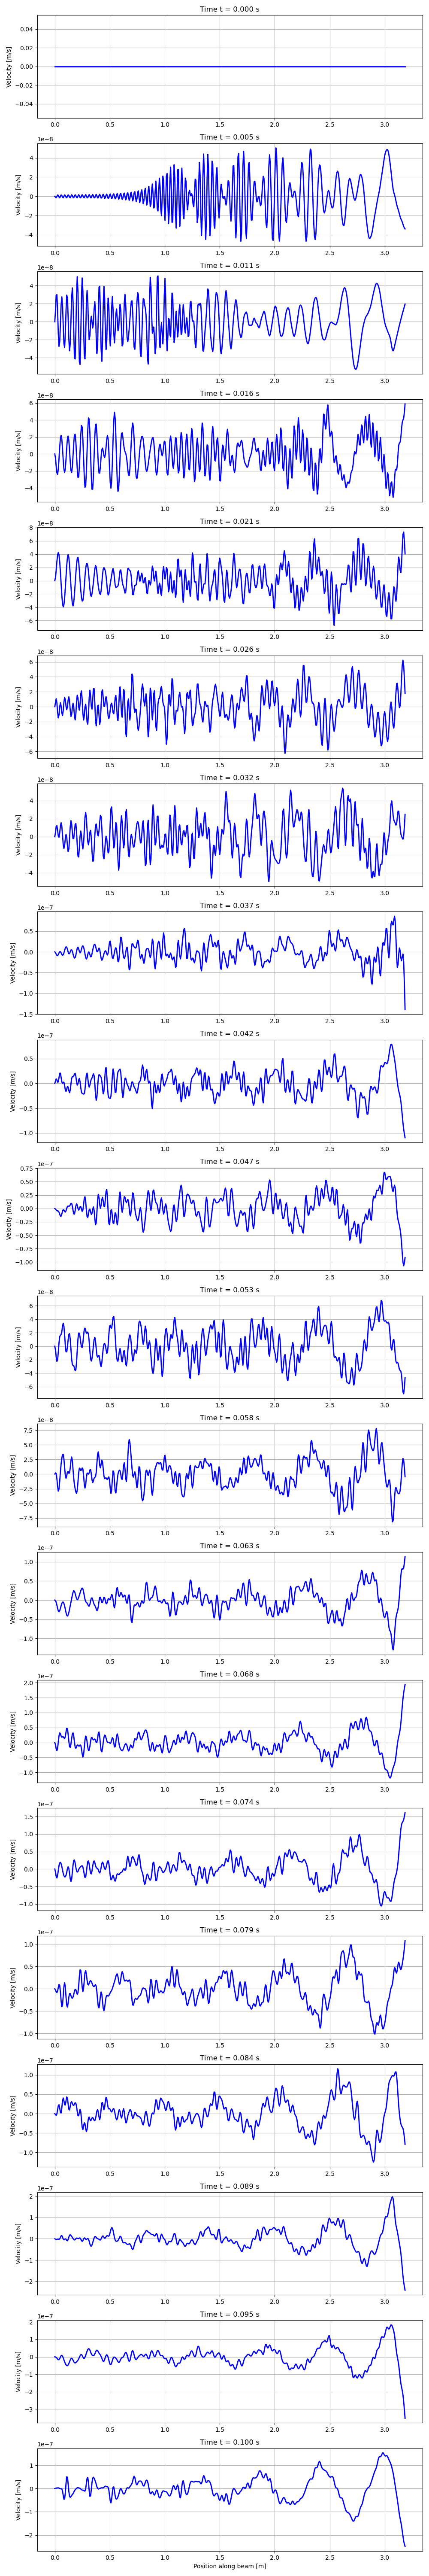

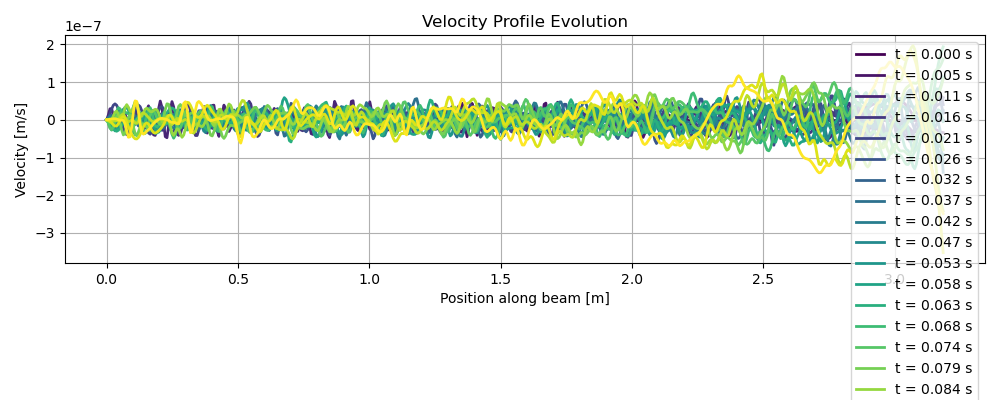

In [68]:





results = rom.run_time_sim(v_exc=v_exc, j_exc=299, K_c=K_c, K_p=K_p, K_i=K_i, t_end=t_end, x_eval=x_eval, t_eval=t_eval)
t = results['t']
veloc = results['veloc']
freq = results['freq']
Y = results['Y']
X = results['X']
FRF = results['FRF']

# freq_modal, vel_mag, disp_mag, veloc_frq = rom.frequency_response(j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i,
# 										w=np.linspace(f0, f1, 1000)*2*np.pi, x_eval=x_eval)
# =================== Velocity field at multiple time instances ===================
# Select a few time indices to visualize the spatial velocity profile evolution


n_times = len(t)
# Choose time instances: start, several intermediate times, and end
time_indices = np.linspace(0, n_times - 1, 20, dtype=int)
# time_indices = np.arange(0, 20)  # specific time indices
time_values = t[time_indices]

# Create subplots for each time instance
fig, axes = plt.subplots(len(time_indices), 1, figsize=(10, 3 * len(time_indices)))
if len(time_indices) == 1:
    axes = [axes]

for idx, (ax, t_idx) in enumerate(zip(axes, time_indices)):
    ax.plot(x_eval, veloc[:, t_idx], 'b-', linewidth=2)
    ax.set_ylabel('Velocity [m/s]')
    ax.set_title(f'Time t = {time_values[idx]:.3f} s')
    ax.grid(True)

axes[-1].set_xlabel('Position along beam [m]')
plt.tight_layout()
plt.show()

# Alternative: overlay all on same plot
plt.figure(figsize=(10, 4))
colors = plt.cm.viridis(np.linspace(0, 1, len(time_indices)))
for t_idx, color, t_val in zip(time_indices, colors, time_values):
    plt.plot(x_eval, veloc[:, t_idx], color=color, linewidth=2, label=f't = {t_val:.3f} s')
plt.xlabel('Position along beam [m]')
plt.ylabel('Velocity [m/s]')
plt.title('Velocity Profile Evolution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
veloc.shape
# t_eval.shape

(500, 100000)

ValueError: quantization error

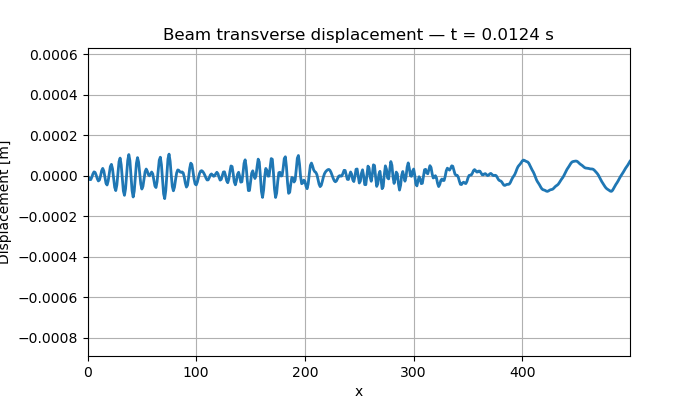

MemoryError: Unable to allocate 1.07 MiB for an array with shape (400, 700) and data type uint32

In [69]:

animate_field_1d(
	t=t_eval,
	u=veloc.T,
	# x=fe.x_nodes_free,
	filename="beam_displacement2.gif",
	scale=2000,
	ylabel="Displacement [m]",
	title="Beam transverse displacement"
)
